# FINANCE 384 --- Lecture 5

## Neural Networks, Part 1: The Basics

Companion to **Lecture 5: Deep Learning, Part 1**. The lecture builds a feed-forward network
out of weighted sums, biases, and activation functions, and makes the point that linear
regression is the no-hidden-layer case. This notebook checks that claim on data we generate
ourselves, where the right answer is known in advance.

A single unit with a linear activation computes

$$\hat{y} = wx + b,$$

which is the regression line. Fitted by gradient descent, its weight and bias should reproduce
the OLS slope and intercept. Section 5 then adds a hidden layer and asks what that buys: the
*universal approximation theorem* states that a feed-forward network with as few as one hidden
layer is a universal approximator, and switching the data generating process from $y = 2x + 1$
to $y = 2x^{2} + 1$ puts the claim to a test.


**After this notebook you should be able to:**

1. build a single-unit linear network in Keras and explain what each argument does;
2. show that its fitted weight and bias recover the OLS estimates, and say why they must;
3. read a Keras model summary and count the parameters a network holds;
4. inspect a training-loss curve and judge whether the network has converged;
5. add a hidden layer, and describe what a non-linear activation adds that a linear one cannot.

## 1. Setup

The data are generated inside the notebook, so nothing needs to be downloaded and the notebook
runs unchanged in Colab. `statsmodels` supplies the OLS benchmark, and TensorFlow Keras supplies
the network that is checked against it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.utils import plot_model

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

SEED = 384
np.random.seed(SEED)        # the simulated sample is the same on every run
tf.random.set_seed(SEED)    # Keras draws the starting weights randomly as well

BLUE = "#003865"
GREEN = "#64A70B"
GOLD = "#F2A900"
RED = "#DA291C"

### 1.1 Sample sizes and helper functions

The sample is split by position: the first `In_Sample` observations are used to fit each model
and the last `Out_of_Sample` observations are held back for evaluation.

Two helpers are defined once and reused by every model below, so the regression and the network
are judged on the same picture and the same score.

In [2]:
# Define the parameters

In_Sample = 2520        # Approximate number of trading days in 10 years

Out_of_Sample = 126     # Approximate number of trading days in six months

In [3]:
def actual_vs_predicted_plot(actual, predicted, in_sample):
    """
    The actual_vs_predicted_plot function visualizes a comparison between actual values and predicted values.
    The plot considers both in-sample and out-of-sample observations
    """
    
    # Plot settings
    fig, ax = plt.subplots(figsize=(14, 7))
    plt.title('Actual vs Predicted Values')
    plt.xlabel('')
    plt.ylabel('')
    
    
    # Historical prices
    ax.plot(actual, color='black', label='Actual')
    ax.plot(predicted[:in_sample],
              color='Blue',
              label='Predicted (in-sample)')
    ax.plot(predicted[in_sample:],
              color='Red',
              label='Predicted (out-of-sample)')
    
    # plt.legend()
    plt.tight_layout()
    plt

In [4]:
def r_squared_score(actual, predicted):
    
    """
    Calculate and print the R2 score between actual and predicted values.
    """

    r_squared = r2_score(actual, predicted)

    print(f"R-squared value: {r_squared}")

## 2. The data

The data set initially represents a simple linear relationship, $y = 2x + 1$, which is split
into a training block and a test block. Section 5 replaces it with the non-linear
$y = 2x^{2} + 1$.

In [5]:
# Sample Data: 
# Start with a simple linear relationship (y = 2x + 1)
# Then consider a non-linear relationship (y = 2x**2 + 1)

X = np.random.rand(In_Sample+Out_of_Sample, 1)  # 100 samples, 1 feature
y = 2 * X + 1

# Create a DataFrame
df = pd.DataFrame({
    'X': X.flatten(),
    'y': y.flatten()
})

df_train = df[:In_Sample]
df_test = df[In_Sample:]

df

,X,y
0,0.7856,2.5712
1,0.2848,1.5695
2,0.7227,2.4455
3,0.7679,2.5357
4,0.4493,1.8986
...,...,...
2641,0.7658,2.5316
2642,0.6388,2.2777
2643,0.0380,1.0759
2644,0.4701,1.9402


## 3. The benchmark: linear regression

The benchmark is the linear regression model estimated by OLS, taken from `statsmodels`. The
same fit can be obtained from `scikit-learn`, following the textbook.

Because the data were generated as $y = 2x + 1$ with no noise, OLS should return
$\hat{\beta}_0 = 1$ and $\hat{\beta}_1 = 2$ exactly, up to floating-point error. That is the
target the network has to hit in section 4.

In [6]:
indep_var = ['X']

# Assuming df_train['y'] is your dependent variable and df_train['x'] your independent variable
y = df_train['y']

# Add a constant to the model (for the intercept)
X = sm.add_constant(df_train[indep_var])

# Fit the model
# Make sure the dependent variable (y) is the first argument
model = sm.OLS(y, X).fit()

# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.043e+33
Date:                Thu, 20 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:22:44   Log-Likelihood:                 83717.
No. Observations:                2520   AIC:                        -1.674e+05
Df Residuals:                    2518   BIC:                        -1.674e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0000   3.59e-17   2.79e+16      0.0

### 3.1 Assessing the accuracy of the model

R-squared value: 1.0


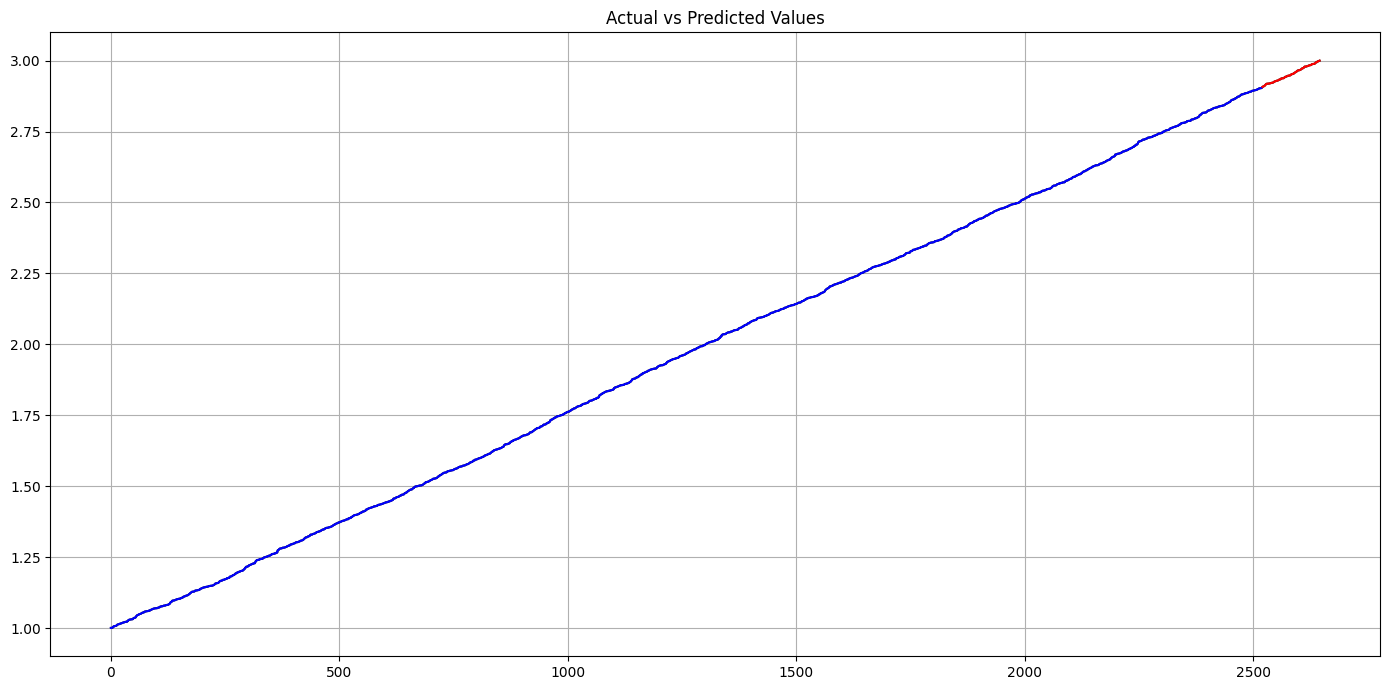

In [7]:
y_pred = model.predict(sm.add_constant(df[indep_var]))

df_reg = pd.DataFrame({
    'obs': df['y'],
    'pred': y_pred
})
df_reg = df_reg.sort_values(by=['obs']).reset_index()

actual_vs_predicted_plot(df_reg['obs'], df_reg['pred'], In_Sample)

y_pred_oos = model.predict(sm.add_constant(df_test[indep_var]))
r_squared_score(df_test[['y']], y_pred_oos)

## 4. The neural network

We begin with a simple network of one unit and a linear activation function, built with the
TensorFlow Keras package. One unit, one input, and a bias give two parameters --- the same two
OLS just estimated.

In [8]:
def neural_netork(input_dim):
  model = Sequential()

  # A single Dense layer (perceptron) with 1 unit and a linear activation function
  model.add(Dense(1, input_shape=(input_dim,), activation='linear'))

  # Compile the model
  # The optimizer is set to 'adam', and the loss function to 'mean_squared_error'
  model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                loss='mean_squared_error'
                )

  # Summary of the model to see its structure
  print(model.summary())

  return model

In [9]:
# Train the model
# Using df_train['x'] as input and df_train['y'] as the target

indep_var = ['X']

model = neural_netork(len(indep_var))
history = model.fit(df_train[indep_var].values, df_train['y'].values,
                    epochs=10,
                    batch_size=16,
                    validation_split=0,
                    verbose=0,
                    shuffle=False
                    )

/Users/justincase/Documents/Finance384/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

None


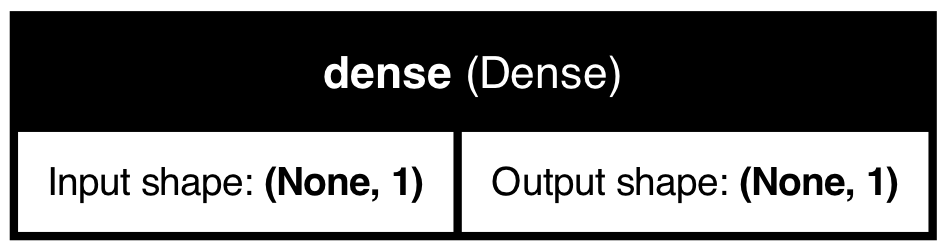

In [10]:
plot_model(model, show_shapes=True, show_layer_names=True)

In [11]:
# Print the weights and biases

"""
This code iterates through each layer of a model, retrieves and prints the weights and biases for every layer,
specifying each layer's position in the sequence.
"""

for layer in model.layers:
    weights, biases = layer.get_weights()
    print(f"Weights of layer {model.layers.index(layer)+1}: {weights}")
    print(f"Biases of layer {model.layers.index(layer)+1}: {biases}")

Weights of layer 1: [[1.9306972]]
Biases of layer 1: [1.0371013]


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
R-squared value: 0.9987781047821045


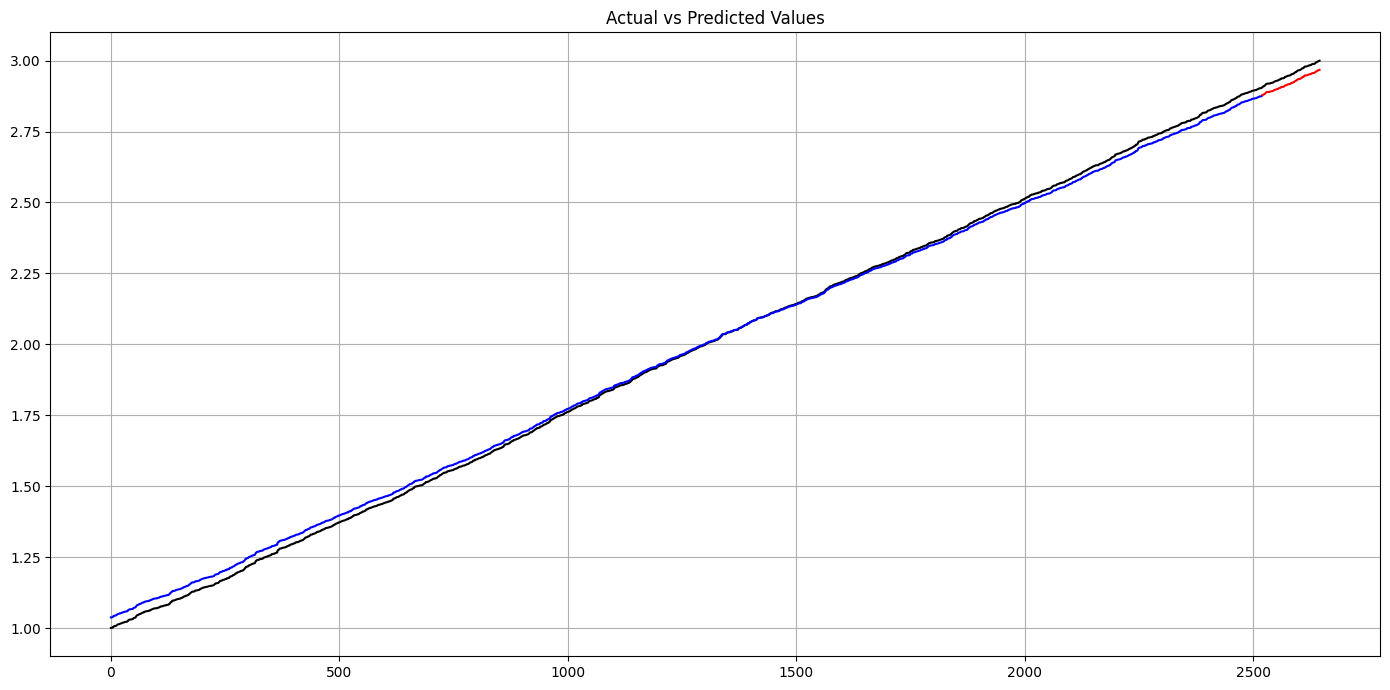

In [12]:
# Generate predictions
y_pred = pd.Series(model.predict(df[indep_var]).flatten())  # Flatten is used to ensure the prediction array shape matches the target array
y_pred.index = df.index


df_reg = pd.DataFrame({
    'obs': df['y'],
    'pred': y_pred
})
df_reg = df_reg.sort_values(by=['obs']).reset_index()

actual_vs_predicted_plot(df_reg['obs'], df_reg['pred'], In_Sample)


y_pred_oos = pd.Series(model.predict(df_test[indep_var]).flatten())
y_pred_oos.index = df_test.index

r_squared_score(df_test[['y']], y_pred_oos)

## 5. To do

1. Run both the OLS regression and the neural network replicating it, and compare the fitted
   weight and bias against the OLS coefficients.

2. Then consider the **universal approximation theorem**: multilayer feed-forward networks with
   as few as one hidden layer are universal approximators.

   Add a hidden layer to the network, then assess whether it can fit both the linear function
   and the non-linear one, $y = 2x^{2} + 1$.

   - first try linear activation functions;
   - then try non-linear (ReLU) activations.

3. Does the depth and the width of the network matter? The loss curve below is the place to
   start: re-run it after each change and compare.

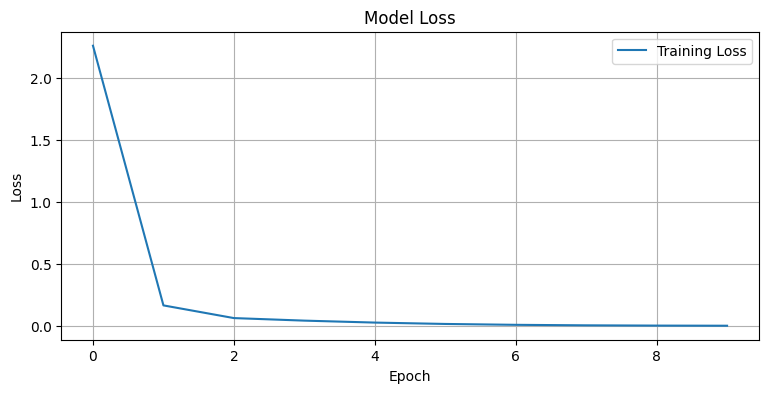

In [13]:
plt.plot(history.history['loss'], label='Training Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()